# pdfplumber-First PDF Extraction Pipeline

A **two-path architecture** where pdfplumber is the single entry point:

```
                    ┌──────────────────┐
                    │   pdfplumber     │
                    │   Open PDF       │
                    └────────┬─────────┘
                             │
                    ┌────────▼─────────┐
                    │  PDF Triage      │
                    │  per-page:       │
                    │  • chars count   │
                    │  • image area    │
                    │  • find_tables() │
                    │  • curves/rects  │
                    └───┬─────────┬────┘
                        │         │
              has text? YES       NO → needs OCR
                        │         │
               ┌────────▼──┐  ┌──▼──────────────┐
               │  PATH A   │  │    PATH B        │
               │  Native   │  │  pdfplumber grids│
               │  Extract  │  │  → crop regions  │
               └────┬──────┘  │  → OCR only those│
                    │         └──────┬───────────┘
                    │                │
                    └───────┬────────┘
                            │
                   ┌────────▼─────────┐
                   │  LLM Processing  │
                   │  Marker / pymu4l │
                   │  → markdown +    │
                   │    structured    │
                   └──────────────────┘
```

| Path | When | What |
|------|------|------|
| **A — Native** | PDF has embedded text (digital/native) | pdfplumber extracts text, tables, chart data directly |
| **B — OCR-Assisted** | Scanned PDF / image-based pages | pdfplumber detects regions → crop → targeted OCR (Tesseract vs RapidOCR) |
| **LLM Stage** | Always | Marker or pymupdf4llm → markdown + structured data for LLM consumption |

---
## Phase 1: Setup & PDF Intelligence
### 1.1 — Environment & Imports

In [61]:
# Dependencies — uncomment to install:
%pip install -q pdfplumber pymupdf pymupdf4llm pytesseract rapidocr-onnxruntime pandas numpy matplotlib marker-pdf
# NOTE: Tesseract also needs a system install:
#brew install tesseract tesseract-lang
#   Ubuntu: sudo apt install tesseract-ocr tesseract-ocr-por

Note: you may need to restart the kernel to use updated packages.


In [62]:
%pip install marker-pdf


Note: you may need to restart the kernel to use updated packages.


In [63]:
import os, sys, re, time, json, warnings, io
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
import logging
import marker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Primary: pdfplumber (structure + native text)
import pdfplumber

# PyMuPDF (for pixmap rendering + LLM markdown)
import fitz
import pymupdf4llm

# OCR engines — both optional, benchmarked in Path B
TESSERACT_AVAILABLE = False
try:
    import pytesseract
    from pytesseract import Output
    # Quick check that tesseract binary is installed
    pytesseract.get_tesseract_version()
    TESSERACT_AVAILABLE = True
except Exception:
    warnings.warn("Tesseract not available. Install: brew install tesseract tesseract-lang && pip install pytesseract")

RAPIDOCR_AVAILABLE = False
try:
    from rapidocr_onnxruntime import RapidOCR
    RAPIDOCR_AVAILABLE = True
except ImportError:
    warnings.warn("RapidOCR not available. Install: pip install rapidocr-onnxruntime")

# Marker (optional — for LLM markdown generation)
MARKER_AVAILABLE = False
try:
    from marker.convert import convert_single_pdf
    from marker.models import load_all_models
    MARKER_AVAILABLE = True
except ImportError:
    warnings.warn("Marker not available. Install: pip install marker-pdf")

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

print(f"Python {sys.version.split()[0]}")
print(f"pdfplumber {pdfplumber.__version__} | PyMuPDF {fitz.__doc__}")
print(f"Tesseract: {'✓' if TESSERACT_AVAILABLE else '✗'}")
print(f"RapidOCR:  {'✓' if RAPIDOCR_AVAILABLE else '✗'}")
print(f"Marker:    {'✓' if MARKER_AVAILABLE else '✗'}")

Python 3.13.5
pdfplumber 0.11.9 | PyMuPDF PyMuPDF 1.27.2.2: Python bindings for the MuPDF 1.27.2 library.
Python 3.13 running on darwin (64-bit).

Tesseract: ✓
RapidOCR:  ✓
Marker:    ✗


/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_1040/112935078.py:45: UserWarning: Marker not available. Install: pip install marker-pdf
  warnings.warn("Marker not available. Install: pip install marker-pdf")


### 1.2 — Configuration & Data Models

Single dataclass holds all thresholds. The key models (`TableCell`, `ExtractedTable`, `ChartData`)
are shared by both Path A and Path B.

In [64]:
@dataclass
class ExtractionConfig:
    """Centralized configuration for the pdfplumber-first pipeline."""
    pdf_path: str = "./sample.pdf"
    output_dir: Path = field(default_factory=lambda: Path("./pdfplumber_output"))

    # Triage thresholds
    text_coverage_threshold: float = 0.05   # below this → needs OCR
    image_area_threshold: float = 0.50      # images covering >50% of page → likely scanned

    # Table detection
    snap_tolerance: float = 3.0
    intersection_tolerance: float = 5.0
    table_settings: Dict = field(default_factory=lambda: {
        "vertical_strategy": "lines",
        "horizontal_strategy": "lines",
        "snap_tolerance": 3,
        "intersection_tolerance": 5,
        "edge_min_length": 10,
    })

    # Chart detection
    min_curves_for_chart: int = 3           # min Bézier curves to consider a chart region
    min_colored_rects_for_chart: int = 2    # min filled rects to consider bar chart
    chart_cluster_tolerance: float = 20.0   # px to group curves/rects into one chart region

    # OCR (Path B)
    ocr_resolution: int = 300               # DPI for region crops
    tesseract_lang: str = "por+eng"
    min_overlap_pct: float = 0.15           # for IoU cell assignment
    force_ocr: bool = False                 # force OCR even on native pages (for testing)

    def __post_init__(self):
        self.output_dir.mkdir(exist_ok=True, parents=True)


@dataclass
class TableCell:
    """A single table cell with text, position, and classification."""
    row: int
    col: int
    bbox: Tuple[float, float, float, float]  # (x0, top, x1, bottom) — pdfplumber coords
    text: str = ""
    confidence: float = 1.0
    is_price: bool = False
    is_header: bool = False


@dataclass
class ExtractedTable:
    """A full extracted table with cells + DataFrame."""
    page: int
    table_idx: int
    bbox: Tuple[float, float, float, float]
    cells: List[TableCell] = field(default_factory=list)
    df: Optional[pd.DataFrame] = None
    extraction_method: str = ""   # "native" or "ocr_tesseract" or "ocr_rapidocr"
    time_s: float = 0.0

    @property
    def shape(self) -> Tuple[int, int]:
        if self.cells:
            return (max(c.row for c in self.cells) + 1,
                    max(c.col for c in self.cells) + 1)
        return (0, 0)


@dataclass
class ChartData:
    """Extracted data points from a chart region."""
    page: int
    chart_idx: int
    bbox: Tuple[float, float, float, float]
    chart_type: str = "unknown"   # "bar", "line", "scatter", "unknown"
    data_points: List[Dict] = field(default_factory=list)   # [{"label": ..., "value": ...}, ...]
    axis_labels: Dict = field(default_factory=dict)          # {"x": ..., "y": ...}
    raw_curves: int = 0
    raw_rects: int = 0
    extraction_method: str = ""


@dataclass
class PageAnalysis:
    """Triage result for a single page."""
    page_num: int
    width: float
    height: float
    char_count: int = 0
    text_coverage: float = 0.0
    image_coverage: float = 0.0
    line_count: int = 0
    rect_count: int = 0
    curve_count: int = 0
    image_count: int = 0
    has_text: bool = False
    needs_ocr: bool = False
    table_regions: List[Dict] = field(default_factory=list)  # [{"bbox": ..., "n_rows": ..., "n_cols": ...}]
    chart_regions: List[Dict] = field(default_factory=list)  # [{"bbox": ..., "type": ...}]


# ── Initialize ──
config = ExtractionConfig()
assert os.path.exists(config.pdf_path), f"PDF not found: {config.pdf_path}"
print(f"PDF: {config.pdf_path} ({os.path.getsize(config.pdf_path) / 1024:.0f} KB)")
print(f"Output: {config.output_dir}")

PDF: ./sample.pdf (2540 KB)
Output: pdfplumber_output


### 1.3 — Helper Functions

Shared utilities for number parsing, geometry, span processing, and cell assignment.
These are used by both Path A and Path B.

In [65]:
# ── Number Parsing (Brazilian format: 1.234,56) ──

def parse_brazilian_number(val: str) -> Optional[float]:
    """Convert Brazilian format (1.234,56) to float."""
    if not val or not isinstance(val, str):
        return None
    val = re.sub(r"[R$\s]", "", val.strip())
    if val in ("-", "", "n/a", "N/A", "—"):
        return None
    is_pct = "%" in val
    val = val.replace("%", "")
    try:
        val = val.replace(".", "").replace(",", ".")
        result = float(val)
        return result / 100 if is_pct else result
    except ValueError:
        return None


def is_price_like(text: str) -> bool:
    """Check if text looks like a Brazilian price value."""
    if not text:
        return False
    return bool(re.search(r'R?\$?\s*\d{1,3}(?:\.\d{3})*,\d{2}(?!\d)', text))


def extract_numeric_values(text: str) -> List[str]:
    """Extract all price-like values and percentages from text."""
    if not text:
        return []
    prices = re.findall(r'(?<![.\d])\d+[,\.]\d{1,3}(?![\d%])', text)
    pcts = re.findall(r'-?\d+[,\.]\d{1,2}%', text)
    return prices + pcts


# ── Geometry ──

def bbox_overlap_area(a, b) -> float:
    """Intersection area of two (x0, y0, x1, y1) bboxes."""
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    return max(0, x1 - x0) * max(0, y1 - y0)


def bbox_iou(a, b) -> float:
    """IoU of two bboxes."""
    inter = bbox_overlap_area(a, b)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)


def span_area(bbox) -> float:
    return max(0, (bbox[2] - bbox[0]) * (bbox[3] - bbox[1]))


def point_in_bbox(px, py, bbox) -> bool:
    return bbox[0] <= px <= bbox[2] and bbox[1] <= py <= bbox[3]


def expand_bbox(bbox, padding=2.0):
    return (bbox[0] - padding, bbox[1] - padding,
            bbox[2] + padding, bbox[3] + padding)


def bboxes_overlap(a, b) -> bool:
    """Check if two bboxes overlap at all."""
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


def validate_bbox(bbox, page_width, page_height) -> bool:
    """Validate bbox has no negative coords and is within page bounds."""
    x0, y0, x1, y1 = bbox
    if x0 < -5 or y0 < -5 or x1 < 0 or y1 < 0:
        return False
    if x1 <= x0 or y1 <= y0:
        return False
    area = (x1 - x0) * (y1 - y0)
    if area < 100:
        return False
    return True


# ── Span Processing (for Path B OCR results) ──

def split_multi_value_span(span: Dict) -> List[Dict]:
    """Split spans containing multiple price values or product names into individual sub-spans.

    Fix 3: Handles concatenated values like "7,45 6,50" and mixed text+prices
    like "Flake Cristal PET Flake Verde PET 6,40 6,25".
    """
    text = span["text"]

    # Pattern 1: Multiple price-like values separated by spaces (e.g., "7,45 6,50")
    tokens = re.findall(r'-?\d{1,3}(?:\.\d{3})*,\d{2}%?', text)
    if len(tokens) <= 1:
        # Pattern 2: Check if text has product names concatenated with prices
        # e.g., "Flake Cristal PET Flake Verde PET 6,40 6,25"
        price_tokens = re.findall(r'\d+,\d{2}', text)
        if len(price_tokens) > 1:
            tokens = price_tokens
        else:
            return [span]

    x0, y0, x1, y1 = span["bbox"]
    total_width = x1 - x0
    total_len = max(len(text), 1)
    sub_spans = []
    for tok in tokens:
        pos = text.find(tok)
        if pos < 0:
            continue
        frac_start = pos / total_len
        frac_end = (pos + len(tok)) / total_len
        sub_spans.append({
            "text": tok,
            "bbox": (round(x0 + total_width * frac_start, 1), y0,
                     round(x0 + total_width * frac_end, 1), y1),
            "confidence": span.get("confidence", 0),
            "origin": "split",
        })
        # Advance text to avoid re-matching the same token
        text = text[:pos] + (" " * len(tok)) + text[pos + len(tok):]

    # Also extract non-numeric label portions as separate spans
    remaining_text = re.sub(r'\d+,\d{2}%?', '', span["text"]).strip()
    label_parts = [p.strip() for p in re.split(r'\s{2,}', remaining_text) if p.strip() and len(p.strip()) > 2]
    if label_parts and sub_spans:
        # Add label spans at the beginning
        label_width = total_width * 0.4  # approximate
        for i, lbl in enumerate(label_parts):
            lbl_frac = i / max(len(label_parts), 1)
            sub_spans.insert(i, {
                "text": lbl,
                "bbox": (round(x0 + label_width * lbl_frac, 1), y0,
                         round(x0 + label_width * (lbl_frac + 1/len(label_parts)), 1), y1),
                "confidence": span.get("confidence", 0),
                "origin": "split_label",
            })

    return sub_spans if sub_spans else [span]


def merge_nearby_spans(spans: List[Dict],
                       x_tolerance: float = 5.0,
                       y_tolerance: float = 2.0) -> List[Dict]:
    """Merge spans on the same line and close in X."""
    if not spans:
        return spans
    sorted_spans = sorted(spans, key=lambda s: (s["bbox"][1], s["bbox"][0]))
    merged = [sorted_spans[0]]
    for span in sorted_spans[1:]:
        last = merged[-1]
        lb, cb = last["bbox"], span["bbox"]
        y_overlap = (cb[1] < lb[3] + y_tolerance and cb[3] > lb[1] - y_tolerance)
        x_close = abs(cb[0] - lb[2]) < x_tolerance
        if y_overlap and x_close:
            last["text"] = last["text"] + " " + span["text"]
            last["bbox"] = (min(lb[0], cb[0]), min(lb[1], cb[1]),
                            max(lb[2], cb[2]), max(lb[3], cb[3]))
        else:
            merged.append(span)
    return merged


def assign_span_to_cell(span_bbox, cell_bboxes: Dict[Tuple[int, int], tuple],
                         min_overlap_pct: float = 0.15) -> Optional[Tuple[int, int]]:
    """Assign span to best-matching cell using IoU + overlap, with center-point fallback."""
    best_cell = None
    best_score = 0.0
    sa = span_area(span_bbox)
    if sa > 0:
        for (row, col), cell_bbox in cell_bboxes.items():
            overlap = bbox_overlap_area(span_bbox, cell_bbox)
            overlap_pct = overlap / sa
            iou = bbox_iou(span_bbox, cell_bbox)
            score = max(overlap_pct, iou * 0.5)
            if score > best_score and overlap_pct >= min_overlap_pct:
                best_score = score
                best_cell = (row, col)
    if best_cell is None:
        cx = (span_bbox[0] + span_bbox[2]) / 2
        cy = (span_bbox[1] + span_bbox[3]) / 2
        for (row, col), cell_bbox in cell_bboxes.items():
            if point_in_bbox(cx, cy, cell_bbox):
                return (row, col)
    return best_cell


def deduplicate_rows(rows: List[List[str]], similarity_threshold: float = 0.85) -> List[List[str]]:
    """Remove near-duplicate rows from OCR output (Fix 3).

    OCR can produce duplicate rows when text spans straddle row boundaries.
    Two rows are considered duplicates if they share >85% of their non-empty cells.
    """
    if len(rows) <= 1:
        return rows

    def row_similarity(r1, r2):
        if len(r1) != len(r2):
            return 0.0
        non_empty = 0
        matching = 0
        for a, b in zip(r1, r2):
            a_s, b_s = str(a).strip(), str(b).strip()
            if a_s or b_s:
                non_empty += 1
                if a_s == b_s:
                    matching += 1
        return matching / non_empty if non_empty > 0 else 0.0

    unique_rows = [rows[0]]
    for row in rows[1:]:
        is_dup = False
        for existing in unique_rows:
            if row_similarity(row, existing) >= similarity_threshold:
                is_dup = True
                break
        if not is_dup:
            unique_rows.append(row)

    return unique_rows


def split_concatenated_cell_values(cell_text: str) -> List[str]:
    """Split a cell containing multiple concatenated price values (Fix 3).

    E.g., "7,45 6,50" → ["7,45", "6,50"]
    """
    if not cell_text:
        return [cell_text]
    prices = re.findall(r'-?\d{1,3}(?:\.\d{3})*,\d{2}', cell_text)
    if len(prices) > 1:
        return prices
    return [cell_text]


def ocr_region_to_image_and_spans(page, bbox, config, preferred_engine="tesseract"):
    """Crop a region, OCR it, return spans. Used by hybrid triage and chart-to-table.

    Shared utility for Fix 1 (hybrid triage) and Fix 5 (chart→table).
    """
    try:
        cropped = page.crop(bbox)
        im = cropped.to_image(resolution=config.ocr_resolution)
        pil_img = im.original
    except Exception as e:
        logger.warning(f"Failed to crop region {bbox}: {e}")
        return [], None

    spans = []
    if preferred_engine == "tesseract" and TESSERACT_AVAILABLE:
        spans = ocr_tesseract(pil_img, config.tesseract_lang)
    elif RAPIDOCR_AVAILABLE:
        spans = ocr_rapidocr(pil_img)
    elif TESSERACT_AVAILABLE:
        spans = ocr_tesseract(pil_img, config.tesseract_lang)

    return spans, pil_img


# ── Metrics ──

def compute_metrics(found: List[str], ground_truth: List[str]) -> Dict[str, float]:
    """Multiset precision / recall / F1."""
    found_counter = Counter(found)
    gt_counter = Counter(ground_truth)
    tp = sum(min(found_counter[v], gt_counter[v]) for v in found_counter if v in gt_counter)
    fp = sum(found_counter[v] for v in found_counter) - tp
    fn = sum(gt_counter[v] for v in gt_counter) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {"found": len(found), "gt": len(ground_truth), "tp": tp,
            "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}


def build_dataframe_from_rows(rows: List[List[str]]) -> pd.DataFrame:
    """Build DataFrame from row lists with smart header detection."""
    if not rows or len(rows) < 2:
        return pd.DataFrame(rows) if rows else pd.DataFrame()
    df = pd.DataFrame(rows)
    first_row = df.iloc[0]
    text_ratio = sum(
        1 for v in first_row
        if isinstance(v, str) and v and not re.match(r'^[\d\s,\.\-%]+$', v)
    ) / max(len(first_row), 1)
    if text_ratio > 0.5:
        df.columns = [str(v).strip() or f"col_{i}" for i, v in enumerate(first_row)]
        df = df.iloc[1:].reset_index(drop=True)
    return df


# Global storage for cross-pipeline comparison
TIMINGS = {}
PIPELINE_VALUES = {}

print("Helpers loaded.")

Helpers loaded.


---
### 1.4 — PDF Triage: Per-Page Analysis

Open the PDF with pdfplumber and analyze each page to determine:
- **Text coverage**: ratio of `chars` area to page area. Below 5% → likely scanned.
- **Image coverage**: large images covering >50% of page → likely scanned.
- **Structural elements**: lines/rects (even scanned PDFs may have vector table grids).
- **Decision**: `needs_ocr = True` if text coverage is low.

This is the **routing step** that decides Path A vs Path B for each page.

In [66]:
def triage_page(page: pdfplumber.page.Page, config: ExtractionConfig) -> PageAnalysis:
    """Analyze a single pdfplumber page and determine extraction strategy."""
    page_num = page.page_number
    page_area = page.width * page.height

    # ── Text coverage ──
    chars = page.chars
    char_count = len(chars)
    if chars:
        text_area = sum((c["x1"] - c["x0"]) * (c["bottom"] - c["top"]) for c in chars)
        text_coverage = text_area / page_area if page_area > 0 else 0
    else:
        text_coverage = 0.0

    # ── Image coverage ──
    images = page.images
    image_count = len(images)
    if images:
        image_area = sum((im["x1"] - im["x0"]) * (im["bottom"] - im["top"]) for im in images)
        image_coverage = image_area / page_area if page_area > 0 else 0
    else:
        image_coverage = 0.0

    # ── Structural elements ──
    line_count = len(page.lines)
    rect_count = len(page.rects)
    curve_count = len(page.curves)

    # ── Decision ──
    has_text = text_coverage > config.text_coverage_threshold
    needs_ocr = (not has_text) or config.force_ocr

    return PageAnalysis(
        page_num=page_num, width=page.width, height=page.height,
        char_count=char_count, text_coverage=text_coverage,
        image_coverage=image_coverage, line_count=line_count,
        rect_count=rect_count, curve_count=curve_count,
        image_count=image_count, has_text=has_text, needs_ocr=needs_ocr,
    )


# ── Run triage on all pages ──
pdf = pdfplumber.open(config.pdf_path)
page_analyses: List[PageAnalysis] = []

print(f"{'Page':>4}  {'Chars':>6}  {'Text%':>6}  {'Img%':>6}  {'Lines':>5}  {'Rects':>5}  {'Curves':>6}  {'Images':>6}  {'Route'}")
print("-" * 75)

for page in pdf.pages:
    pa = triage_page(page, config)
    page_analyses.append(pa)
    route = "PATH B (OCR)" if pa.needs_ocr else "PATH A (native)"
    print(f"{pa.page_num:>4}  {pa.char_count:>6}  {pa.text_coverage:>5.1%}  "
          f"{pa.image_coverage:>5.1%}  {pa.line_count:>5}  {pa.rect_count:>5}  "
          f"{pa.curve_count:>6}  {pa.image_count:>6}  {route}")

native_pages = [pa for pa in page_analyses if not pa.needs_ocr]
ocr_pages = [pa for pa in page_analyses if pa.needs_ocr]
print(f"\nSummary: {len(native_pages)} native pages, {len(ocr_pages)} OCR pages")

Page   Chars   Text%    Img%  Lines  Rects  Curves  Images  Route
---------------------------------------------------------------------------
   1     454   5.0%  240.3%     36     52       6     165  PATH A (native)
   2     805   6.1%  234.8%     57   1024      21     304  PATH A (native)
   3     665   5.0%  232.7%     54    875      21     281  PATH B (OCR)
   4     663   4.7%  235.2%     56   1074      21     336  PATH B (OCR)
   5     612   4.5%  237.9%     55    709      21     248  PATH B (OCR)
   6     605   4.2%  231.2%     48    676      21     278  PATH B (OCR)
   7     479   3.8%  223.5%     50    297      19     156  PATH B (OCR)
   8     196   1.5%  228.6%      2     63       2      60  PATH B (OCR)

Summary: 2 native pages, 6 OCR pages


### 1.5 — Region Detection: Tables & Charts

For each page, detect **where** the interesting content lives:

- **Tables**: `page.find_tables()` returns `Table` objects with `.bbox`, `.rows`, `.cells`
- **Charts**: Heuristic — cluster `curves` (Bézier paths) and colored `rects` (bar fills) that are **outside table regions**
- **Images**: `page.images` — raster images that may be charts or figures

The visual debug overlay shows table regions (blue) and chart candidates (green).

In [67]:
def detect_table_regions(page: pdfplumber.page.Page, config: ExtractionConfig) -> List[Dict]:
    """Detect table regions using pdfplumber's find_tables()."""
    tables = page.find_tables(table_settings=config.table_settings)
    regions = []
    for tbl in tables:
        rows = tbl.rows
        if not rows or len(rows) < 2:
            continue
        n_cols = max(len(r.cells) for r in rows)
        cell_bboxes = {}
        for r_idx, row in enumerate(rows):
            for c_idx, cell in enumerate(row.cells):
                if cell:
                    cell_bboxes[(r_idx, c_idx)] = tuple(cell)
        regions.append({
            "type": "table",
            "bbox": tbl.bbox,
            "cell_bboxes": cell_bboxes,
            "n_rows": len(rows),
            "n_cols": n_cols,
        })
    return regions


def detect_chart_regions(page: pdfplumber.page.Page, table_bboxes: List[tuple],
                         config: ExtractionConfig) -> List[Dict]:
    """Detect chart/graph regions by finding clusters of curves and colored rects outside tables.

    Fix 2 improvements:
    - Raised min image area from 2000 → 15000 to filter tiny logos/icons
    - Validates bbox (rejects negative coordinates)
    - Detects bottom-of-page graph sections (colored rects clusters) for OCR
    """

    def is_inside_any_table(obj_bbox):
        obj_center = ((obj_bbox[0] + obj_bbox[2]) / 2, (obj_bbox[1] + obj_bbox[3]) / 2)
        for tb in table_bboxes:
            if point_in_bbox(obj_center[0], obj_center[1], tb):
                return True
        return False

    chart_objects = []  # (x0, top, x1, bottom, type)

    # Curves (Bézier paths) — common in line/area charts
    for curve in page.curves:
        c_bbox = (curve["x0"], curve["top"], curve["x1"], curve["bottom"])
        # Fix 2: validate bbox — reject negative coordinates
        if not validate_bbox(c_bbox, page.width, page.height):
            continue
        if not is_inside_any_table(c_bbox) and curve["width"] > 5 and curve["height"] > 5:
            chart_objects.append((*c_bbox, "curve"))

    # Colored/filled rects — common in bar charts (exclude table borders: thin, no fill)
    for rect in page.rects:
        r_bbox = (rect["x0"], rect["top"], rect["x1"], rect["bottom"])
        # Fix 2: validate bbox
        if not validate_bbox(r_bbox, page.width, page.height):
            continue
        has_fill = rect.get("non_stroking_color") is not None
        is_thick = rect["width"] > 3 and rect["height"] > 3
        if not is_inside_any_table(r_bbox) and has_fill and is_thick:
            # Exclude very large rects (likely page background) and tiny ones
            area = rect["width"] * rect["height"]
            page_area = page.width * page.height
            if 100 < area < page_area * 0.5:
                chart_objects.append((*r_bbox, "rect"))

    # Raster images outside tables — may be embedded chart images
    for img in page.images:
        i_bbox = (img["x0"], img["top"], img["x1"], img["bottom"])
        # Fix 2: validate bbox
        if not validate_bbox(i_bbox, page.width, page.height):
            continue
        if not is_inside_any_table(i_bbox):
            area = (img["x1"] - img["x0"]) * (img["bottom"] - img["top"])
            img_width = img["x1"] - img["x0"]
            img_height = img["bottom"] - img["top"]
            # Fix 2: raised from 2000 → 15000 to filter tiny logos/icons (26x18px etc.)
            if area > 15000 and img_width > 50 and img_height > 50:
                chart_objects.append((*i_bbox, "image"))

    if not chart_objects:
        return []

    # ── Cluster nearby objects into chart regions ──
    tol = config.chart_cluster_tolerance
    clusters = []
    used = [False] * len(chart_objects)

    for i, obj in enumerate(chart_objects):
        if used[i]:
            continue
        cluster = [obj]
        used[i] = True
        # Expand cluster with nearby objects
        changed = True
        while changed:
            changed = False
            cluster_bbox = (
                min(o[0] for o in cluster) - tol,
                min(o[1] for o in cluster) - tol,
                max(o[2] for o in cluster) + tol,
                max(o[3] for o in cluster) + tol,
            )
            for j, obj2 in enumerate(chart_objects):
                if used[j]:
                    continue
                if bboxes_overlap(cluster_bbox, obj2[:4]):
                    cluster.append(obj2)
                    used[j] = True
                    changed = True
        clusters.append(cluster)

    # ── Build chart region from each cluster ──
    regions = []
    for cluster in clusters:
        n_curves = sum(1 for o in cluster if o[4] == "curve")
        n_rects = sum(1 for o in cluster if o[4] == "rect")
        n_images = sum(1 for o in cluster if o[4] == "image")

        # Only consider it a chart if there are enough elements
        is_chart = (
            n_curves >= config.min_curves_for_chart or
            n_rects >= config.min_colored_rects_for_chart or
            n_images >= 1
        )
        if not is_chart:
            continue

        bbox = (
            min(o[0] for o in cluster),
            min(o[1] for o in cluster),
            max(o[2] for o in cluster),
            max(o[3] for o in cluster),
        )

        # Fix 2: final bbox validation — reject regions with invalid bounds
        if not validate_bbox(bbox, page.width, page.height):
            logger.info(f"Rejected chart region with invalid bbox: {bbox}")
            continue

        chart_type = "unknown"
        if n_curves > n_rects:
            chart_type = "line"
        elif n_rects > n_curves:
            chart_type = "bar"
        elif n_images > 0:
            chart_type = "image"

        # Fix 2/5: Flag if this looks like a graph rendered as colored rects
        # (bottom portion of page with many colored rects = likely a bar chart to OCR)
        is_bottom_graph = (
            n_rects >= 5 and
            bbox[1] > page.height * 0.4 and  # in bottom 60% of page
            (bbox[3] - bbox[1]) > 30          # has meaningful height
        )

        regions.append({
            "type": "chart",
            "chart_type": chart_type,
            "bbox": bbox,
            "n_curves": n_curves,
            "n_rects": n_rects,
            "n_images": n_images,
            "is_bottom_graph": is_bottom_graph,  # Fix 5: used for chart→table OCR
        })

    return regions


# ── Run region detection on all pages ──
for pa in page_analyses:
    page = pdf.pages[pa.page_num - 1]

    # Tables
    pa.table_regions = detect_table_regions(page, config)

    # Charts (excluding table areas)
    table_bboxes = [r["bbox"] for r in pa.table_regions]
    pa.chart_regions = detect_chart_regions(page, table_bboxes, config)

# ── Summary ──
print(f"{'Page':>4}  {'Tables':>6}  {'Charts':>6}  {'Chart Types'}")
print("-" * 50)
for pa in page_analyses:
    chart_types = [r["chart_type"] for r in pa.chart_regions] if pa.chart_regions else ["-"]
    print(f"{pa.page_num:>4}  {len(pa.table_regions):>6}  {len(pa.chart_regions):>6}  {', '.join(chart_types)}")

total_tables = sum(len(pa.table_regions) for pa in page_analyses)
total_charts = sum(len(pa.chart_regions) for pa in page_analyses)
print(f"\nTotal: {total_tables} tables, {total_charts} chart regions detected")

Page  Tables  Charts  Chart Types
--------------------------------------------------
   1       5       0  -
   2       4       0  -
   3       6       0  -
   4       4       0  -
   5       4       0  -
   6       5       0  -
   7       5       0  -
   8       1       0  -

Total: 34 tables, 0 chart regions detected


### 1.6 — Visual Debug: Detected Regions

Draw detected regions on the page image:
- **Blue** = table regions
- **Green** = chart regions
- Shows the first page with detections (or the most interesting page).


Page 1 (Native) — 5 tables (blue), 0 charts (green)


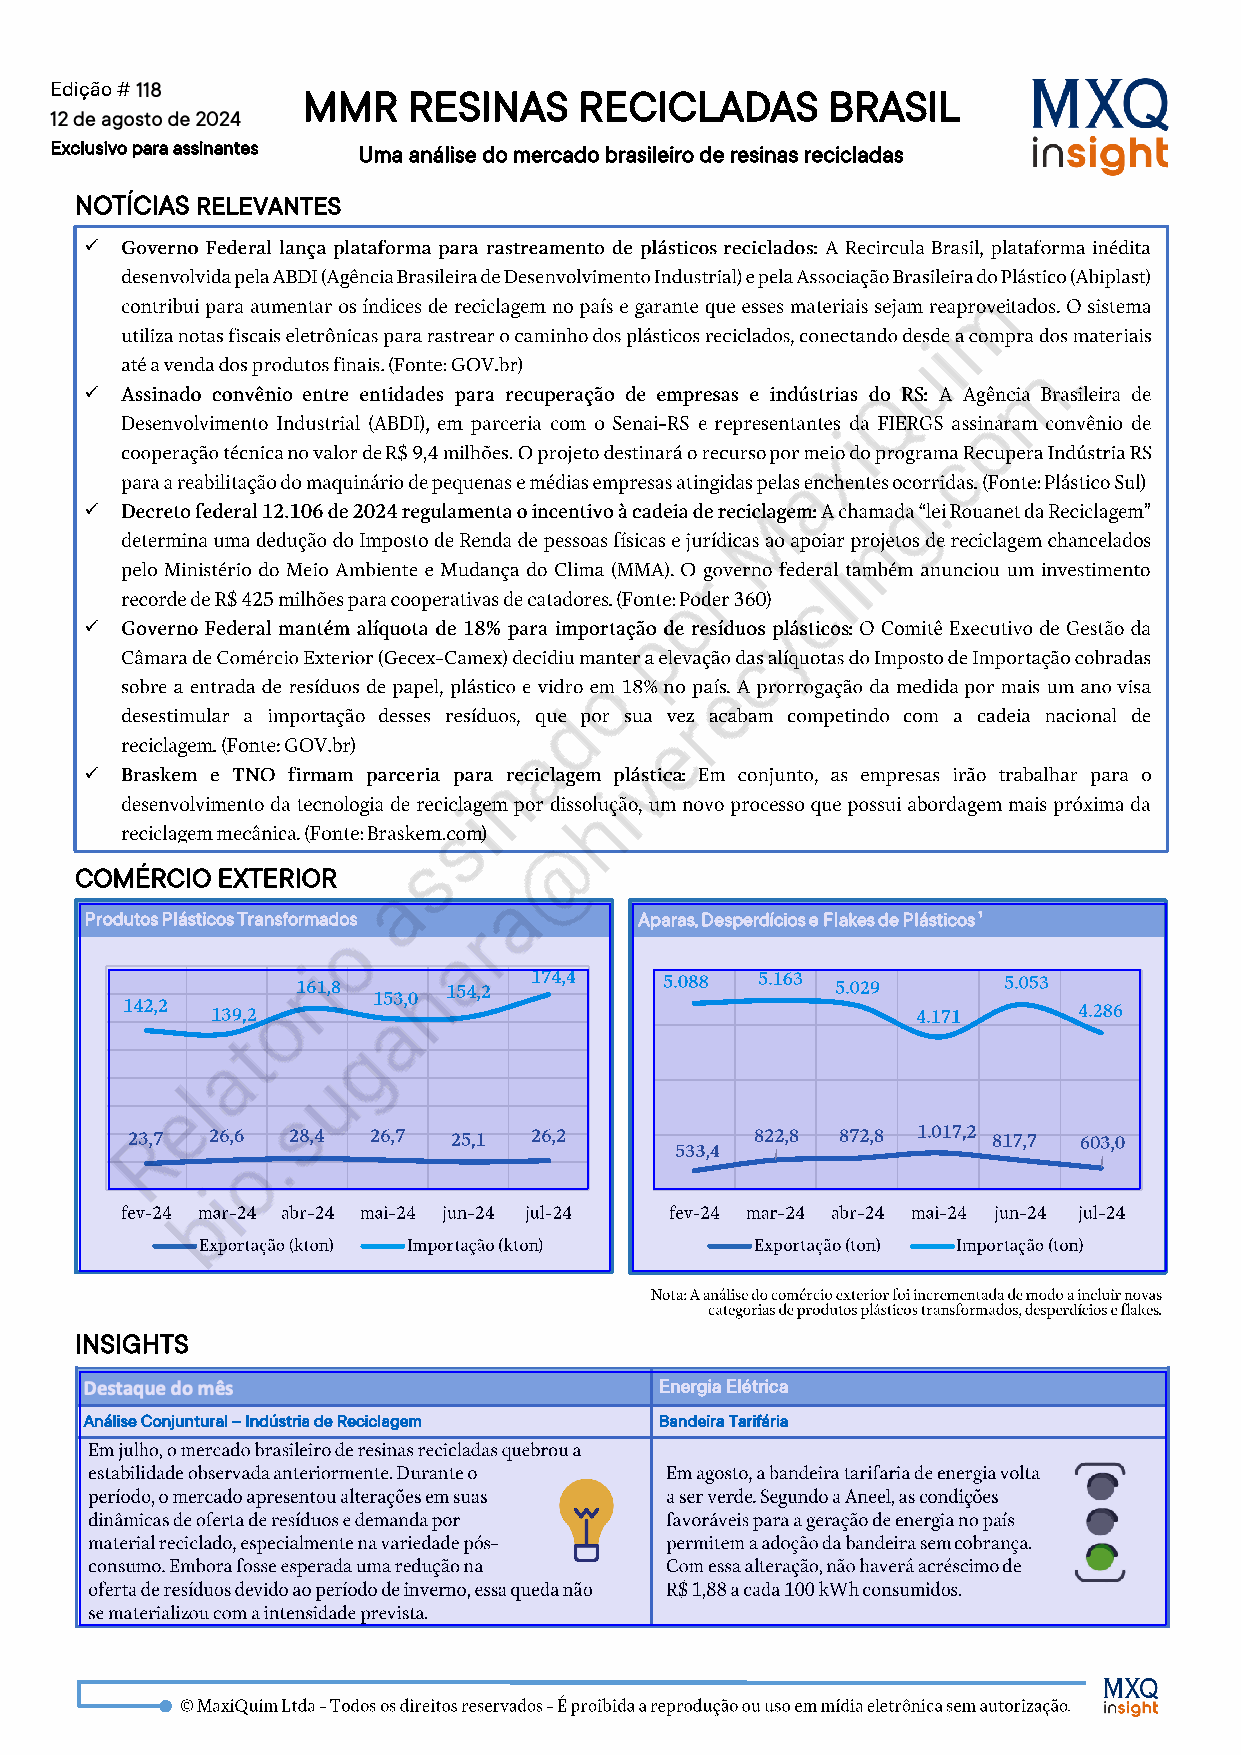


Page 2 (Native) — 4 tables (blue), 0 charts (green)


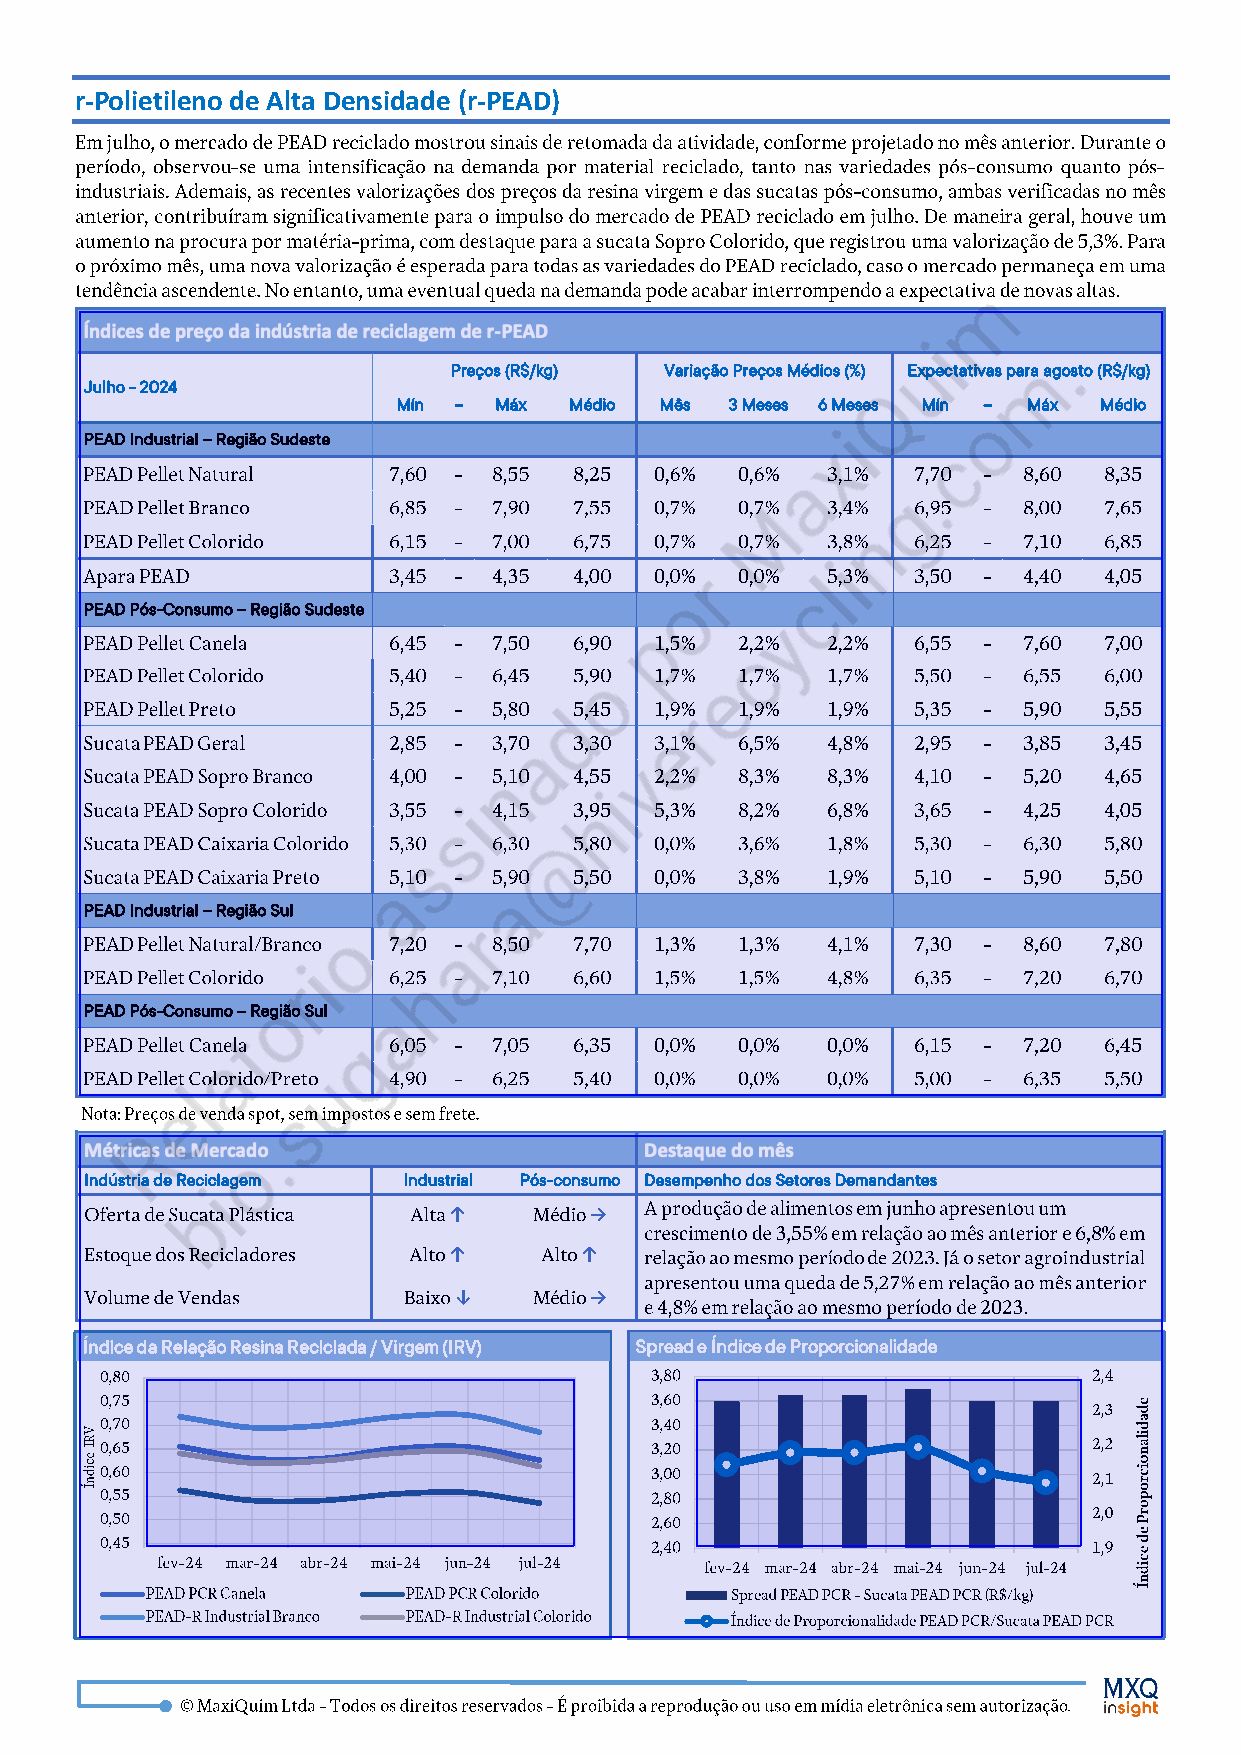


Page 3 (OCR) — 6 tables (blue), 0 charts (green)


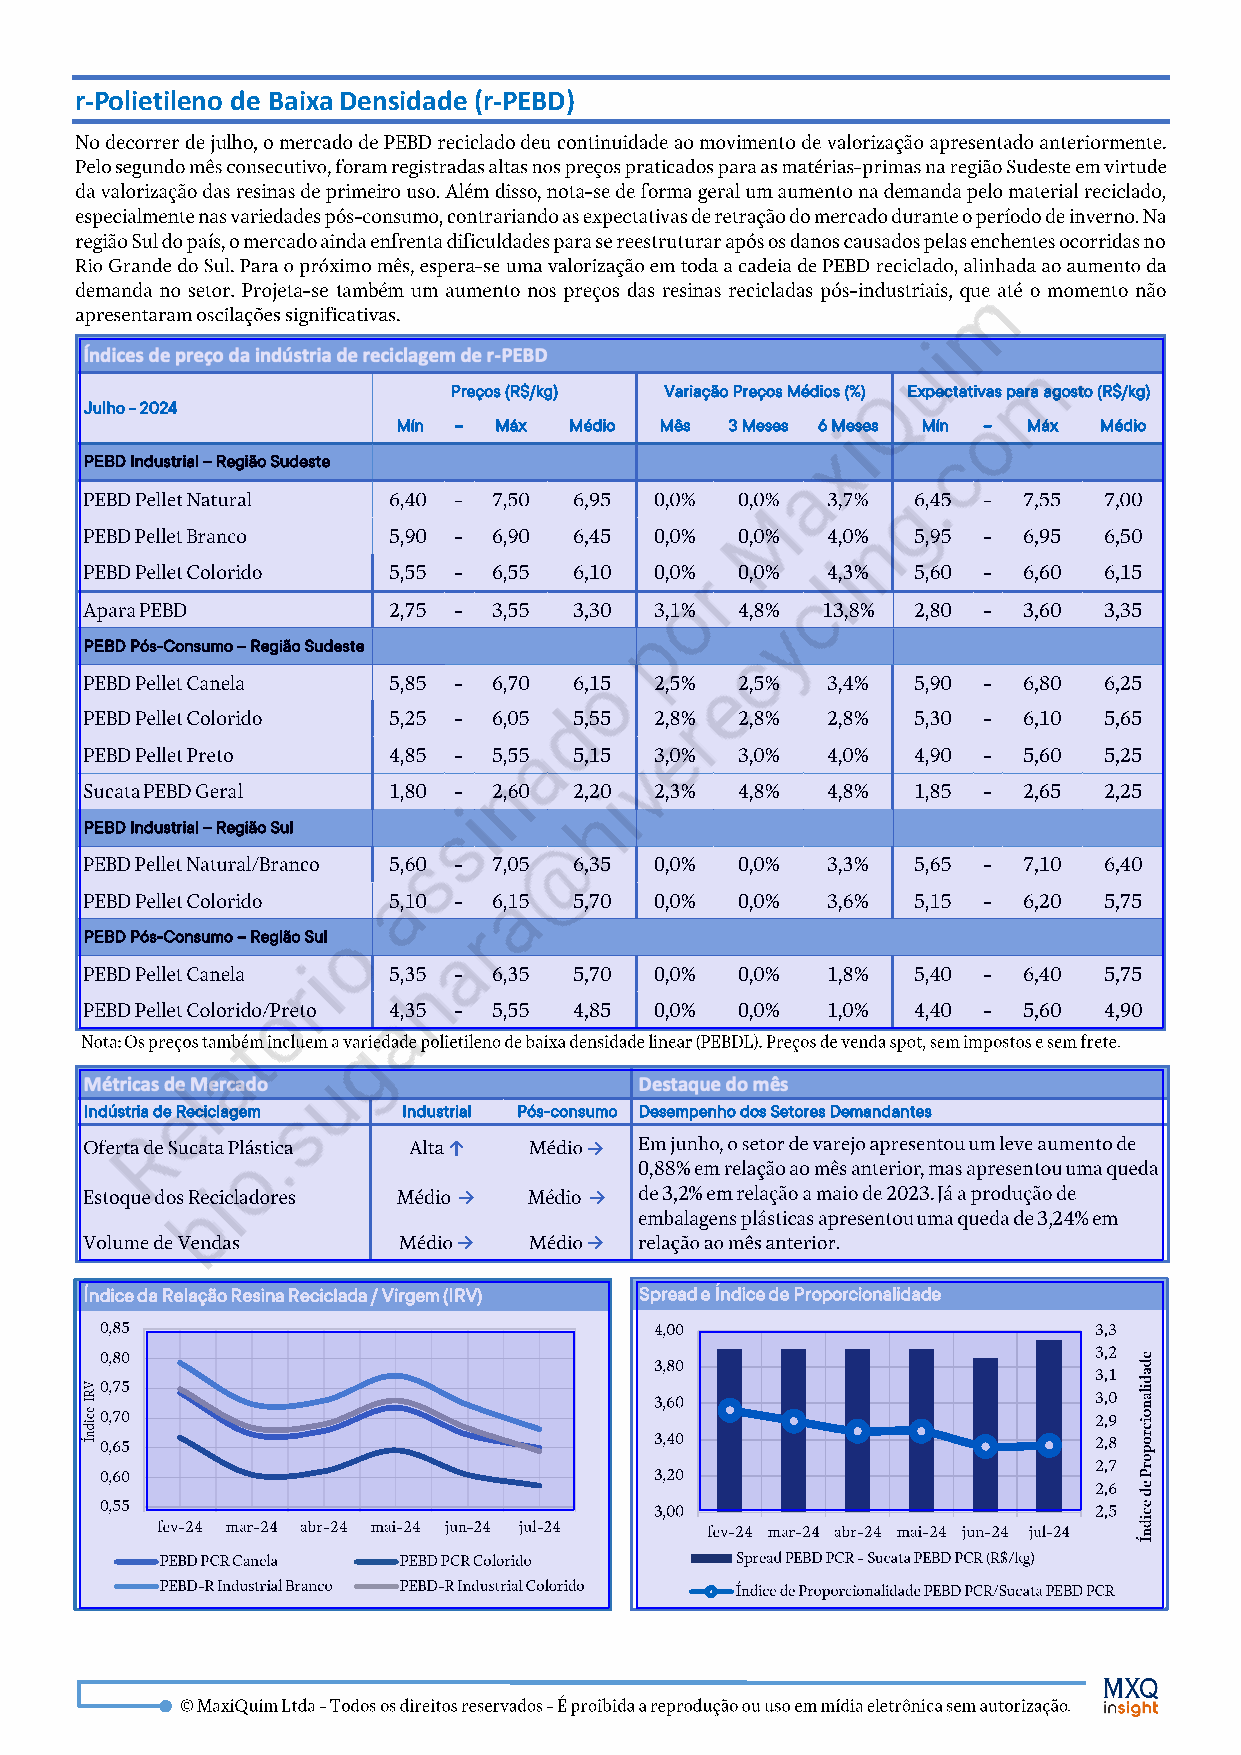

In [68]:
def visualize_regions(page: pdfplumber.page.Page, analysis: PageAnalysis, resolution: int = 150):
    """Draw table (blue) and chart (green) regions on page image."""
    im = page.to_image(resolution=resolution)

    # Draw table regions in blue
    for region in analysis.table_regions:
        im.draw_rect(region["bbox"], fill=(0, 0, 200, 30), stroke="blue", stroke_width=2)

    # Draw chart regions in green
    for region in analysis.chart_regions:
        im.draw_rect(region["bbox"], fill=(0, 200, 0, 30), stroke="green", stroke_width=2)

    return im


# Show pages that have detected regions
pages_with_regions = [pa for pa in page_analyses if pa.table_regions or pa.chart_regions]

if pages_with_regions:
    # Show up to 3 most interesting pages
    for pa in pages_with_regions[:3]:
        page = pdf.pages[pa.page_num - 1]
        route = "OCR" if pa.needs_ocr else "Native"
        print(f"\nPage {pa.page_num} ({route}) — "
              f"{len(pa.table_regions)} tables (blue), "
              f"{len(pa.chart_regions)} charts (green)")
        im = visualize_regions(page, pa)
        display(im)
else:
    # Show first page with tablefinder debug overlay
    page = pdf.pages[0]
    print(f"No regions detected via heuristics. Showing tablefinder debug for page 1:")
    im = page.to_image(resolution=150)
    display(im.debug_tablefinder(config.table_settings))

---
## Phase 2: Path A — Native Text Extraction

For pages where `needs_ocr = False` (the PDF has embedded text), pdfplumber can extract
everything directly — no OCR needed.

### 2.1 — Table Extraction (Native)

Two approaches shown side by side:
1. `extract_tables()` — returns cell text directly as nested lists
2. `find_tables()` — returns geometry (cell bboxes) — useful for structured output

In [69]:
t0 = time.time()
native_tables: List[ExtractedTable] = []

# Fix 1: Track tables that need OCR fallback
tables_needing_ocr_fallback = []

for pa in page_analyses:
    if pa.needs_ocr and not config.force_ocr:
        continue  # Skip OCR pages — handled in Path B
    if not pa.table_regions:
        continue

    page = pdf.pages[pa.page_num - 1]

    # ── Method 1: extract_tables() — get cell text directly ──
    raw_tables = page.extract_tables(table_settings=config.table_settings)

    for tbl_idx, (raw_rows, region) in enumerate(zip(raw_tables, pa.table_regions)):
        if not raw_rows or len(raw_rows) < 2:
            continue

        # Clean None → ""
        cleaned_rows = [
            [cell.strip() if cell else "" for cell in row]
            for row in raw_rows
        ]

        # Build cells with classification
        cells = []
        for r_idx, row in enumerate(cleaned_rows):
            for c_idx, text in enumerate(row):
                cell_bbox = region["cell_bboxes"].get((r_idx, c_idx), (0, 0, 0, 0))
                cells.append(TableCell(
                    row=r_idx, col=c_idx, bbox=cell_bbox,
                    text=text, is_price=is_price_like(text),
                ))

        # ── Fix 1: Hybrid Triage — check if table has >70% empty VALUE cells ──
        # Skip the header row (row 0); only consider value rows
        value_cells = [c for c in cells if c.row > 0]
        n_value_cells = len(value_cells)
        n_empty_value = sum(1 for c in value_cells if not c.text.strip())
        empty_ratio = n_empty_value / n_value_cells if n_value_cells > 0 else 0

        if empty_ratio > 0.70 and n_value_cells >= 4:
            # This table has native text but the actual data values are probably
            # vector fill paths (not text). Queue it for OCR re-extraction.
            logger.info(f"Page {pa.page_num} Table {tbl_idx}: {empty_ratio:.0%} empty value cells "
                        f"({n_empty_value}/{n_value_cells}) — queuing for OCR fallback")
            tables_needing_ocr_fallback.append({
                "page_num": pa.page_num,
                "tbl_idx": tbl_idx,
                "region": region,
                "pa": pa,
            })
            continue  # Don't add the empty native table

        # Build DataFrame
        df = build_dataframe_from_rows(cleaned_rows)

        table = ExtractedTable(
            page=pa.page_num, table_idx=tbl_idx, bbox=region["bbox"],
            cells=cells, df=df, extraction_method="native",
        )
        native_tables.append(table)

# ── Fix 1: OCR fallback for tables with too many empty cells ──
if tables_needing_ocr_fallback:
    print(f"\nFix 1: Re-extracting {len(tables_needing_ocr_fallback)} tables via OCR fallback...")
    for info in tables_needing_ocr_fallback:
        page = pdf.pages[info["page_num"] - 1]
        region = info["region"]

        spans, pil_img = ocr_region_to_image_and_spans(page, region["bbox"], config)

        if spans:
            cells = map_ocr_spans_to_grid(spans, region, config)
            if cells:
                n_rows = max(c.row for c in cells) + 1
                n_cols = max(c.col for c in cells) + 1
                data = [["" for _ in range(n_cols)] for _ in range(n_rows)]
                for cell in cells:
                    data[cell.row][cell.col] = cell.text
                # Fix 3: deduplicate rows
                data = deduplicate_rows(data)
                df = build_dataframe_from_rows(data)

                table = ExtractedTable(
                    page=info["page_num"], table_idx=info["tbl_idx"],
                    bbox=region["bbox"], cells=cells, df=df,
                    extraction_method="native_ocr_fallback",
                )
                native_tables.append(table)
                n_ocr_vals = sum(1 for c in cells if extract_numeric_values(c.text))
                print(f"  Page {info['page_num']} Table {info['tbl_idx']}: "
                      f"OCR recovered {len(cells)} cells, {n_ocr_vals} with values")
            else:
                print(f"  Page {info['page_num']} Table {info['tbl_idx']}: OCR spans found but no cells mapped")
        else:
            print(f"  Page {info['page_num']} Table {info['tbl_idx']}: No OCR engine available or no text found")

native_time = time.time() - t0

# ── Collect values ──
native_values = []
for tbl in native_tables:
    for cell in tbl.cells:
        native_values.extend(extract_numeric_values(cell.text))

TIMINGS["Path A: Native Tables"] = native_time
PIPELINE_VALUES["Path A: Native Tables"] = native_values

# ── Summary ──
print(f"\nPath A — Native Table Extraction (with hybrid OCR fallback)")
print(f"Time: {native_time:.2f}s")
print(f"Tables: {len(native_tables)}")
print(f"  Pure native: {sum(1 for t in native_tables if t.extraction_method == 'native')}")
print(f"  OCR fallback: {sum(1 for t in native_tables if t.extraction_method == 'native_ocr_fallback')}")
print(f"Values: {len(native_values)}")
print()

for tbl in native_tables:
    n_prices = sum(1 for c in tbl.cells if c.is_price)
    n_filled = sum(1 for c in tbl.cells if c.text.strip())
    print(f"  Page {tbl.page} Table {tbl.table_idx}: {tbl.shape}, "
          f"filled={n_filled}/{len(tbl.cells)}, prices={n_prices}, method={tbl.extraction_method}")

# Show sample DataFrame
if native_tables:
    sample = next((t for t in native_tables if t.df is not None and not t.df.empty), None)
    if sample:
        print(f"\nSample (Page {sample.page} Table {sample.table_idx}):")
        with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 25):
            display(sample.df.head(5))

2026-03-26 13:20:29,377 - INFO - Page 1 Table 2: 100% empty value cells (42/42) — queuing for OCR fallback
2026-03-26 13:20:29,378 - INFO - Page 1 Table 3: 100% empty value cells (18/18) — queuing for OCR fallback
2026-03-26 13:20:29,402 - INFO - Page 2 Table 0: 97% empty value cells (255/264) — queuing for OCR fallback
2026-03-26 13:20:29,402 - INFO - Page 2 Table 2: 100% empty value cells (72/72) — queuing for OCR fallback
2026-03-26 13:20:29,402 - INFO - Page 2 Table 3: 100% empty value cells (102/102) — queuing for OCR fallback



Fix 1: Re-extracting 5 tables via OCR fallback...
  Page 1 Table 2: OCR recovered 13 cells, 2 with values
  Page 1 Table 3: OCR recovered 5 cells, 3 with values
  Page 2 Table 0: OCR recovered 125 cells, 100 with values
  Page 2 Table 2: No OCR engine available or no text found
  Page 2 Table 3: No OCR engine available or no text found

Path A — Native Table Extraction (with hybrid OCR fallback)
Time: 3.15s
Tables: 7
  Pure native: 4
  OCR fallback: 3
Values: 114

  Page 1 Table 0: (2, 1), filled=1/2, prices=0, method=native
  Page 1 Table 1: (2, 1), filled=1/2, prices=0, method=native
  Page 1 Table 4: (3, 2), filled=4/6, prices=0, method=native
  Page 2 Table 1: (6, 3), filled=8/18, prices=0, method=native
  Page 1 Table 2: (6, 5), filled=13/13, prices=0, method=native_ocr_fallback
  Page 1 Table 3: (2, 6), filled=5/5, prices=0, method=native_ocr_fallback
  Page 2 Table 0: (23, 12), filled=125/125, prices=67, method=native_ocr_fallback

Sample (Page 1 Table 0):


,Produtos Plásticos Transformados
0,


### 2.2 — Chart Data Point Extraction (Vector)

For chart regions detected in Phase 1, try to extract data points programmatically:

1. **Crop** the page to the chart bbox
2. **Curves** → `curve["pts"]` gives (x, y) coordinate lists — these are the data series in line charts
3. **Colored rects** → bar heights encode values
4. **Text within region** → axis labels, tick values, legend entries
5. **Heuristic mapping** → map visual coordinates to data values using axis tick labels

> **Note**: This is experimental. Vector chart extraction is heuristic-heavy and depends on
> how the chart was rendered in the PDF. If this cell produces low-quality results,
> the chart image can be sent to an LLM vision model instead.

In [70]:
def extract_chart_data(page: pdfplumber.page.Page, chart_region: Dict,
                       page_analysis: PageAnalysis) -> ChartData:
    """Extract data points from a chart region using vector elements + text."""
    bbox = chart_region["bbox"]
    chart_type = chart_region.get("chart_type", "unknown")

    # Crop page to chart region
    try:
        cropped = page.crop(bbox)
    except Exception as e:
        logger.warning(f"Could not crop chart region {bbox}: {e}")
        return ChartData(
            page=page_analysis.page_num, chart_idx=0, bbox=bbox,
            chart_type=chart_type, extraction_method="native_failed"
        )

    # ── Extract text elements in the chart area ──
    words = cropped.extract_words(x_tolerance=3, y_tolerance=3)
    text_in_chart = cropped.extract_text(x_tolerance=3, y_tolerance=3) or ""

    # ── Extract curves (line chart data series) ──
    curves = cropped.curves
    curve_data = []
    for curve in curves:
        pts = curve.get("pts", [])
        if len(pts) >= 2:  # a real data series has multiple points
            curve_data.append({
                "points": [(round(x, 1), round(y, 1)) for x, y in pts],
                "color": curve.get("stroking_color"),
                "n_points": len(pts),
            })

    # ── Extract colored rects (bar chart bars) ──
    rects = cropped.rects
    bar_data = []
    for rect in rects:
        has_fill = rect.get("non_stroking_color") is not None
        is_significant = rect["width"] > 2 and rect["height"] > 2
        if has_fill and is_significant:
            bar_data.append({
                "bbox": (rect["x0"], rect["top"], rect["x1"], rect["bottom"]),
                "width": round(rect["width"], 1),
                "height": round(rect["height"], 1),
                "color": rect["non_stroking_color"],
            })

    # ── Try to identify axis labels from words ──
    # Heuristic: words at the bottom are X-axis labels, words on the left are Y-axis labels
    chart_height = bbox[3] - bbox[1]
    chart_width = bbox[2] - bbox[0]

    x_axis_words = [w for w in words if w["top"] > chart_height * 0.75]  # bottom 25%
    y_axis_words = [w for w in words if w["x0"] < chart_width * 0.15]     # left 15%

    x_labels = [w["text"] for w in sorted(x_axis_words, key=lambda w: w["x0"])]
    y_labels = [w["text"] for w in sorted(y_axis_words, key=lambda w: w["top"])]

    # ── Build data points ──
    data_points = []

    if chart_type == "bar" and bar_data:
        # Sort bars left-to-right, use height as relative value
        sorted_bars = sorted(bar_data, key=lambda b: b["bbox"][0])
        for i, bar in enumerate(sorted_bars):
            label = x_labels[i] if i < len(x_labels) else f"bar_{i}"
            data_points.append({
                "label": label,
                "visual_height": bar["height"],
                "color": str(bar["color"]),
            })

    elif chart_type == "line" and curve_data:
        for series_idx, series in enumerate(curve_data):
            for pt_idx, (x, y) in enumerate(series["points"]):
                data_points.append({
                    "series": series_idx,
                    "point_idx": pt_idx,
                    "x_visual": x,
                    "y_visual": y,
                    "color": str(series["color"]),
                })

    # ── Extract any numeric values from text in the chart ──
    numeric_values_in_chart = extract_numeric_values(text_in_chart)

    return ChartData(
        page=page_analysis.page_num,
        chart_idx=0,
        bbox=bbox,
        chart_type=chart_type,
        data_points=data_points,
        axis_labels={"x": x_labels, "y": y_labels, "numeric_values": numeric_values_in_chart},
        raw_curves=len(curves),
        raw_rects=len([r for r in rects if r.get("non_stroking_color")]),
        extraction_method="native_vector",
    )


def chart_region_to_table(page: pdfplumber.page.Page, chart_region: Dict,
                          page_num: int, config: ExtractionConfig) -> Optional[ExtractedTable]:
    """Fix 5: OCR a graph region and return it as a structured table.

    For graph regions at the bottom of pages (rendered as colored rects),
    crop and OCR them, then present the extracted values as a structured DataFrame.
    """
    bbox = chart_region["bbox"]

    spans, pil_img = ocr_region_to_image_and_spans(page, bbox, config)
    if not spans:
        return None

    # Group spans into rows by Y coordinate
    y_tolerance = 8.0
    sorted_spans = sorted(spans, key=lambda s: (s["bbox"][1], s["bbox"][0]))

    rows_of_spans = []
    current_row = [sorted_spans[0]]
    for span in sorted_spans[1:]:
        if abs(span["bbox"][1] - current_row[0]["bbox"][1]) < y_tolerance:
            current_row.append(span)
        else:
            rows_of_spans.append(sorted(current_row, key=lambda s: s["bbox"][0]))
            current_row = [span]
    rows_of_spans.append(sorted(current_row, key=lambda s: s["bbox"][0]))

    # Build text rows
    text_rows = []
    for row_spans in rows_of_spans:
        row_texts = [s["text"] for s in row_spans]
        # Split concatenated values within each text
        expanded = []
        for t in row_texts:
            parts = split_concatenated_cell_values(t)
            expanded.extend(parts)
        text_rows.append(expanded)

    if not text_rows:
        return None

    # Normalize column count
    max_cols = max(len(r) for r in text_rows)
    for row in text_rows:
        while len(row) < max_cols:
            row.append("")

    # Deduplicate
    text_rows = deduplicate_rows(text_rows)

    df = build_dataframe_from_rows(text_rows)

    cells = []
    for r_idx, row in enumerate(text_rows):
        for c_idx, text in enumerate(row):
            cells.append(TableCell(
                row=r_idx, col=c_idx,
                bbox=(0, 0, 0, 0),
                text=text,
                is_price=is_price_like(text),
            ))

    return ExtractedTable(
        page=page_num,
        table_idx=0,
        bbox=bbox,
        cells=cells,
        df=df,
        extraction_method="chart_ocr_to_table",
    )


# ── Run chart extraction ──
all_chart_data: List[ChartData] = []
chart_as_tables: List[ExtractedTable] = []  # Fix 5: tables from chart regions

for pa in page_analyses:
    page = pdf.pages[pa.page_num - 1]
    for idx, region in enumerate(pa.chart_regions):
        chart = extract_chart_data(page, region, pa)
        chart.chart_idx = idx
        all_chart_data.append(chart)

        # Fix 5: If this is a bottom-of-page graph (colored rects), also OCR it as a table
        if region.get("is_bottom_graph", False):
            logger.info(f"Page {pa.page_num} Chart {idx}: bottom graph detected — OCR as table")
            tbl = chart_region_to_table(page, region, pa.page_num, config)
            if tbl is not None:
                tbl.table_idx = idx
                chart_as_tables.append(tbl)

# ── Summary ──
if all_chart_data:
    print(f"Chart Data Extracted: {len(all_chart_data)} charts")
    print()
    for cd in all_chart_data:
        print(f"  Page {cd.page} Chart {cd.chart_idx}: type={cd.chart_type}, "
              f"data_points={len(cd.data_points)}, curves={cd.raw_curves}, "
              f"colored_rects={cd.raw_rects}")
        if cd.axis_labels.get("x"):
            print(f"    X labels: {cd.axis_labels['x'][:10]}")
        if cd.axis_labels.get("y"):
            print(f"    Y labels: {cd.axis_labels['y'][:10]}")
        if cd.axis_labels.get("numeric_values"):
            print(f"    Numeric values in chart text: {cd.axis_labels['numeric_values'][:10]}")
        if cd.data_points:
            print(f"    Sample points: {cd.data_points[:5]}")
else:
    print("No chart regions detected on any page.")

# Fix 5: Show chart→table results
if chart_as_tables:
    print(f"\nFix 5: {len(chart_as_tables)} chart regions converted to tables via OCR:")
    for tbl in chart_as_tables:
        n_vals = sum(1 for c in tbl.cells if extract_numeric_values(c.text))
        print(f"  Page {tbl.page} Chart→Table {tbl.table_idx}: {tbl.shape}, "
              f"cells_with_values={n_vals}")
        if tbl.df is not None and not tbl.df.empty:
            with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 25):
                display(tbl.df.head(5))

No chart regions detected on any page.


### 2.3 — Body Text Extraction

Extract text from areas **outside** tables and charts.
Uses `page.crop()` / `page.outside_bbox()` to isolate body text regions.

In [71]:
body_text_by_page = {}

for pa in page_analyses:
    if pa.needs_ocr:
        continue  # Path B handles OCR pages

    page = pdf.pages[pa.page_num - 1]

    # Start with the full page, then exclude table & chart bboxes
    remaining = page
    excluded_bboxes = (
        [r["bbox"] for r in pa.table_regions] +
        [r["bbox"] for r in pa.chart_regions]
    )

    for exc_bbox in excluded_bboxes:
        try:
            remaining = remaining.outside_bbox(exc_bbox)
        except Exception:
            pass  # bbox may be outside page bounds

    text = remaining.extract_text(layout=True, x_tolerance=3, y_tolerance=3) or ""

    # Fix 4: If native body text is empty/whitespace, fall back to full-page OCR
    # with table/chart regions excluded
    if not text.strip() or len(text.strip()) < 20:
        logger.info(f"Page {pa.page_num}: native body text empty — attempting OCR fallback")

        # Use fitz to render full page, then OCR
        try:
            fitz_doc = fitz.open(config.pdf_path)
            fitz_page = fitz_doc[pa.page_num - 1]

            # First try fitz native text extraction
            fitz_text = fitz_page.get_text("text")
            fitz_doc.close()

            if fitz_text.strip() and len(fitz_text.strip()) > len(text.strip()):
                # Remove text that falls within table/chart regions (approximate)
                text = fitz_text
            elif TESSERACT_AVAILABLE or RAPIDOCR_AVAILABLE:
                # Full-page OCR as last resort
                full_page_img = page.to_image(resolution=config.ocr_resolution).original

                if TESSERACT_AVAILABLE:
                    ocr_text = pytesseract.image_to_string(full_page_img, lang=config.tesseract_lang)
                elif RAPIDOCR_AVAILABLE:
                    spans = ocr_rapidocr(full_page_img)
                    ocr_text = " ".join(s["text"] for s in spans)
                else:
                    ocr_text = ""

                if ocr_text.strip():
                    text = ocr_text
                    logger.info(f"Page {pa.page_num}: OCR fallback recovered {len(text)} chars of body text")
        except Exception as e:
            logger.warning(f"Page {pa.page_num}: body text OCR fallback failed: {e}")

    if text.strip():
        body_text_by_page[pa.page_num] = text

# ── Summary ──
print(f"Body text extracted from {len(body_text_by_page)} pages")
for page_num, text in body_text_by_page.items():
    preview = text.strip()[:200].replace('\n', ' ')
    print(f"  Page {page_num}: {len(text)} chars — {preview}...")

Body text extracted from 2 pages
  Page 1: 5313 chars — Edi ção # 118                                                                                       MMR    RESINAS    RECICLADAS       BRASIL                         12 de agosto de 2024              ...
  Page 2: 5311 chars — r-Polietileno de Alta Densidade (r-PEAD)...


---
## Phase 3: Path B — OCR-Assisted Extraction

For pages where `needs_ocr = True` (scanned/image-based PDFs), the strategy is:
1. **pdfplumber still detects structure** — `lines`, `rects`, `find_tables()` work on vector elements even in scanned PDFs
2. **Crop regions to high-res images** — only table and chart bboxes, not the full page
3. **OCR only those cropped areas** — much faster than full-page OCR
4. **Map OCR spans back to pdfplumber grid cells** — using IoU assignment

### 3.1 — Region Cropping

Convert each detected region into a high-resolution PIL image for OCR.

In [72]:
def crop_region_to_image(page: pdfplumber.page.Page, bbox: tuple,
                         resolution: int = 300) -> Optional[Image.Image]:
    """Crop a page region and return as a PIL Image at the specified resolution."""
    try:
        cropped = page.crop(bbox)
        im = cropped.to_image(resolution=resolution)
        return im.original  # PIL Image
    except Exception as e:
        logger.warning(f"Failed to crop region {bbox}: {e}")
        return None


# ── Crop all regions that need OCR ──
ocr_crops = []  # [{"page_num", "region", "image", "type"}]

for pa in page_analyses:
    if not pa.needs_ocr:
        continue

    page = pdf.pages[pa.page_num - 1]

    for region in pa.table_regions:
        img = crop_region_to_image(page, region["bbox"], config.ocr_resolution)
        if img:
            ocr_crops.append({
                "page_num": pa.page_num, "region": region,
                "image": img, "type": "table",
            })

    for region in pa.chart_regions:
        img = crop_region_to_image(page, region["bbox"], config.ocr_resolution)
        if img:
            ocr_crops.append({
                "page_num": pa.page_num, "region": region,
                "image": img, "type": "chart",
            })

print(f"Cropped {len(ocr_crops)} regions for OCR")
for crop_info in ocr_crops:
    img = crop_info["image"]
    print(f"  Page {crop_info['page_num']}: {crop_info['type']} — {img.size[0]}x{img.size[1]}px")

if not ocr_crops:
    print("\nNo pages need OCR — all pages have native text.")
    print("Set config.force_ocr = True to test OCR path on native pages.")

Cropped 25 regions for OCR
  Page 3: table — 2174x1385px
  Page 3: table — 2174x386px
  Page 3: table — 1066x660px
  Page 3: table — 1060x660px
  Page 3: table — 862x363px
  Page 3: table — 769x363px
  Page 4: table — 2180x1627px
  Page 4: table — 2180x978px
  Page 4: table — 862x317px
  Page 4: table — 772x317px
  Page 5: table — 2171x1088px
  Page 5: table — 2171x1101px
  Page 5: table — 862x363px
  Page 5: table — 769x363px
  Page 6: table — 2170x1165px
  Page 6: table — 2170x383px
  Page 6: table — 2170x672px
  Page 6: table — 862x369px
  Page 6: table — 768x369px
  Page 7: table — 2167x581px
  Page 7: table — 2167x433px
  Page 7: table — 2167x672px
  Page 7: table — 862x370px
  Page 7: table — 775x370px
  Page 8: table — 2051x3003px


### 3.2 — OCR Benchmark: Tesseract vs RapidOCR

Run both OCR engines on the same cropped regions and compare:
- **Speed** — time per region
- **Word count** — how many words detected
- **Confidence** — average OCR confidence
- **Values found** — how many numeric values extracted

This lets you make an informed choice about which engine to use.

In [73]:
def ocr_tesseract(img: Image.Image, lang: str = "por+eng") -> List[Dict]:
    """Run Tesseract OCR on a PIL image, return spans with bboxes."""
    if not TESSERACT_AVAILABLE:
        return []
    data = pytesseract.image_to_data(img, lang=lang, output_type=Output.DICT)
    spans = []
    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        conf = int(data["conf"][i])
        if text and conf > 0:
            x, y, w, h = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
            spans.append({
                "text": text,
                "bbox": (x, y, x + w, y + h),
                "confidence": conf / 100.0,
                "engine": "tesseract",
            })
    return spans


def ocr_rapidocr(img: Image.Image) -> List[Dict]:
    """Run RapidOCR on a PIL image, return spans with bboxes."""
    if not RAPIDOCR_AVAILABLE:
        return []
    ocr = RapidOCR()
    # Convert PIL → bytes for RapidOCR
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    result = ocr(buf.read())
    spans = []
    if result and result[0]:
        for box, text, conf in result[0]:
            if text.strip():
                xs = [pt[0] for pt in box]
                ys = [pt[1] for pt in box]
                spans.append({
                    "text": text.strip(),
                    "bbox": (min(xs), min(ys), max(xs), max(ys)),
                    "confidence": float(conf) if conf is not None else 0.0,
                    "engine": "rapidocr",
                })
    return spans


# ── Run benchmark ──
benchmark_results = []

if ocr_crops:
    print(f"{'Region':<30} {'Engine':<12} {'Time':>6} {'Words':>6} {'Conf':>6} {'Values':>7}")
    print("-" * 70)

    for crop_info in ocr_crops:
        img = crop_info["image"]
        label = f"P{crop_info['page_num']}_{crop_info['type']}"

        for engine_name, engine_fn in [("tesseract", ocr_tesseract), ("rapidocr", ocr_rapidocr)]:
            t0 = time.time()
            spans = engine_fn(img) if engine_name == "rapidocr" else engine_fn(img, config.tesseract_lang)
            elapsed = time.time() - t0

            all_text = " ".join(s["text"] for s in spans)
            values = extract_numeric_values(all_text)
            avg_conf = np.mean([s["confidence"] for s in spans]) if spans else 0

            print(f"{label:<30} {engine_name:<12} {elapsed:>5.2f}s {len(spans):>6} "
                  f"{avg_conf:>5.0%} {len(values):>7}")

            benchmark_results.append({
                "region": label, "engine": engine_name,
                "time_s": round(elapsed, 3), "words": len(spans),
                "avg_confidence": round(avg_conf, 3),
                "values_found": len(values),
                "spans": spans,  # keep for next cell
                "crop_info": crop_info,
            })

    # ── Aggregate comparison ──
    if benchmark_results:
        bdf = pd.DataFrame([{k: v for k, v in r.items() if k not in ("spans", "crop_info")}
                            for r in benchmark_results])
        print(f"\n{'─'*70}")
        print("Aggregate by engine:")
        agg = bdf.groupby("engine").agg({
            "time_s": "sum", "words": "sum",
            "avg_confidence": "mean", "values_found": "sum",
        }).round(3)
        display(agg)
else:
    print("No OCR crops to benchmark (all pages are native text).")
    print("To test OCR, set config.force_ocr = True and re-run from Phase 1.")

Region                         Engine         Time  Words   Conf  Values
----------------------------------------------------------------------
P3_table                       tesseract     0.79s    163   94%     108
P3_table                       rapidocr      1.57s    138   74%     108
P3_table                       tesseract     0.20s      0    0%       0
P3_table                       rapidocr      0.90s     20   86%       2
P3_table                       tesseract     0.38s     40   81%       7
P3_table                       rapidocr      0.42s     19   78%       7
P3_table                       tesseract     0.28s     32   89%       6
P3_table                       rapidocr      0.49s     20   77%      15
P3_table                       tesseract     0.13s      0    0%       0
P3_table                       rapidocr      0.22s      0    0%       0
P3_table                       tesseract     0.13s      0    0%       0
P3_table                       rapidocr      0.21s      0    0% 

,time_s,words,avg_confidence,values_found
engine,,,,
rapidocr,18.660,936,0.479,592
tesseract,11.632,1771,0.496,451


### 3.3 — OCR Spans → Structured Tables

Map OCR results back to pdfplumber's table grid using IoU-based cell assignment.
The grid structure comes from pdfplumber (`find_tables()` cell bboxes), and the
text content comes from OCR — combining the strengths of both.

**Note**: Bbox coordinates need scaling — OCR was run on a high-res crop (e.g., 300 DPI)
while pdfplumber works in PDF points (72 DPI). The scale factor = `ocr_resolution / 72`.

In [74]:
def map_ocr_spans_to_grid(spans: List[Dict], region: Dict,
                           config: ExtractionConfig) -> List[TableCell]:
    """Map OCR spans to pdfplumber grid cells via IoU assignment.

    Handles coordinate scaling: OCR works in pixel space (at ocr_resolution DPI),
    while pdfplumber cell_bboxes are in PDF points (72 DPI).
    """
    cell_bboxes = region.get("cell_bboxes", {})
    if not cell_bboxes or not spans:
        return []

    # Scale factor: convert pdfplumber coords → pixel coords
    scale = config.ocr_resolution / 72.0
    region_bbox = region["bbox"]  # (x0, top, x1, bottom) in pdfplumber coords

    # Convert cell_bboxes to pixel coords relative to the crop origin
    pixel_cell_bboxes = {}
    for (row, col), cb in cell_bboxes.items():
        pixel_cell_bboxes[(row, col)] = (
            (cb[0] - region_bbox[0]) * scale,
            (cb[1] - region_bbox[1]) * scale,
            (cb[2] - region_bbox[0]) * scale,
            (cb[3] - region_bbox[1]) * scale,
        )

    # Process spans: expand, split, merge
    processed = []
    for sp in spans:
        sp["bbox"] = expand_bbox(sp["bbox"], 1.0)
        processed.extend(split_multi_value_span(sp))
    processed = merge_nearby_spans(processed)

    # Assign to cells
    cell_contents: Dict[Tuple[int, int], List[str]] = defaultdict(list)
    for sp in processed:
        pos = assign_span_to_cell(sp["bbox"], pixel_cell_bboxes, config.min_overlap_pct)
        if pos:
            cell_contents[pos].append(sp["text"])

    # Build TableCells
    cells = []
    for (row, col), texts in cell_contents.items():
        full_text = " ".join(texts).strip()
        original_bbox = cell_bboxes.get((row, col), (0, 0, 0, 0))
        cells.append(TableCell(
            row=row, col=col, bbox=original_bbox,
            text=full_text, is_price=is_price_like(full_text),
        ))

    return cells


# ── Build OCR tables (using best engine per region) ──
ocr_tables: List[ExtractedTable] = []

if benchmark_results:
    # Group benchmark results by region, pick the engine with more values found
    from itertools import groupby

    sorted_results = sorted(benchmark_results, key=lambda r: r["region"])
    for region_key, group in groupby(sorted_results, key=lambda r: r["region"]):
        candidates = list(group)
        # Pick engine with best values_found, break ties by confidence
        best = max(candidates, key=lambda r: (r["values_found"], r["avg_confidence"]))

        crop_info = best["crop_info"]
        if crop_info["type"] != "table":
            continue  # Charts handled separately

        region = crop_info["region"]
        cells = map_ocr_spans_to_grid(best["spans"], region, config)

        if cells:
            n_rows = max(c.row for c in cells) + 1
            n_cols = max(c.col for c in cells) + 1
            data = [["" for _ in range(n_cols)] for _ in range(n_rows)]
            for cell in cells:
                data[cell.row][cell.col] = cell.text
            df = build_dataframe_from_rows(data)

            table = ExtractedTable(
                page=crop_info["page_num"], table_idx=len(ocr_tables),
                bbox=region["bbox"], cells=cells, df=df,
                extraction_method=f"ocr_{best['engine']}",
                time_s=best["time_s"],
            )
            ocr_tables.append(table)

# ── Collect values ──
ocr_values = []
for tbl in ocr_tables:
    for cell in tbl.cells:
        ocr_values.extend(extract_numeric_values(cell.text))

TIMINGS["Path B: OCR Tables"] = sum(r["time_s"] for r in benchmark_results) if benchmark_results else 0
PIPELINE_VALUES["Path B: OCR Tables"] = ocr_values

# ── Summary ──
print(f"\nPath B — OCR Table Extraction")
print(f"Tables: {len(ocr_tables)}")
print(f"Values: {len(ocr_values)}")
for tbl in ocr_tables:
    n_prices = sum(1 for c in tbl.cells if c.is_price)
    print(f"  Page {tbl.page} Table {tbl.table_idx}: {tbl.shape}, "
          f"prices={n_prices}, method={tbl.extraction_method}")
    if tbl.df is not None and not tbl.df.empty:
        with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 25):
            display(tbl.df.head(3))


Path B — OCR Table Extraction
Tables: 6
Values: 476
  Page 3 Table 0: (21, 12), prices=66, method=ocr_tesseract


,0,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,,
1,,,,,,,,,,,,
2,Sudeste PEBD Industri...,,,,,,,,,,,


  Page 4 Table 1: (22, 12), prices=95, method=ocr_rapidocr


,0,1,2,3,4,5,6,7,8,9,10,11
0,indices de preco da i...,,,,,,,,,,,
1,Julho - 2024,Precos (RS/kg) Max Médio,,,,Variacao Precos Médio...,,,Expectativas para ago...,,,
2,PP Industrial - Regia...,,,,,,,,,,,


  Page 5 Table 2: (13, 12), prices=48, method=ocr_tesseract


...

,0,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,,
1,,,,,,,,,,,,
2,PS Sudeste Industrial...,,,,,,,,,,,


  Page 7 Table 4: (5, 12), prices=12, method=ocr_tesseract


,0,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,,
1,,,,,,,,,,,,
2,PVC Região Sudeste -,,,,,,,,,,,


  Page 8 Table 5: (8, 2), prices=0, method=ocr_tesseract


,0,1
0,,Sobre publicação a
1,edições analisando me...,
2,,Metodologia de análise


---
## Phase 4: LLM-Ready Output

### 4.1 — Markdown Generation (pymupdf4llm / Marker)

Convert the full PDF to LLM-friendly markdown using:
- **pymupdf4llm**: Fast, auto-OCR, outputs clean markdown with tables.
- **Marker** (if available): Higher quality layout understanding via Surya models.

These produce the **narrative context** for an LLM — the structured data (tables, charts)
from Phases 2 & 3 can be appended as supplementary structured data.

In [75]:
# ── pymupdf4llm ──
print("Running pymupdf4llm...")
pymupdf4llm_md = ""
pymupdf4llm_time = 0

# Try without OCR first (safe), then with OCR if needed
for attempt, use_ocr in enumerate([False, True]):
    try:
        t0 = time.time()
        pymupdf4llm_chunks = pymupdf4llm.to_markdown(
            config.pdf_path,
            page_chunks=True,
            write_images=False,
            force_text=True,
            table_strategy="lines",
            show_progress=False,
            **({"force_ocr": True} if use_ocr else {}),
        )
        pymupdf4llm_time = time.time() - t0
        pymupdf4llm_md = "\n\n".join(chunk["text"] for chunk in pymupdf4llm_chunks)

        # If first attempt got enough values, skip OCR retry
        md_nums = re.findall(r'\d+[,\.]\d{2,3}', pymupdf4llm_md)
        if len(md_nums) >= 5:
            if use_ocr:
                print("  force_ocr=True succeeded.")
            break
        elif not use_ocr:
            print(f"  Only {len(md_nums)} numeric values found — retrying with force_ocr=True...")
            continue
    except Exception as e:
        label = "force_ocr" if use_ocr else "default"
        print(f"  pymupdf4llm ({label}) failed: {type(e).__name__}: {e}")
        if not use_ocr:
            print("  Retrying with force_ocr=True...")
            continue
        else:
            print("  Both attempts failed.")
            break

# ── Fix 4: fitz.open() + page.get_text("text") fallback ──
if len(pymupdf4llm_md.strip()) < 50:
    print("  pymupdf4llm produced insufficient output — falling back to fitz.get_text()...")
    try:
        t0 = time.time()
        fitz_doc = fitz.open(config.pdf_path)
        fitz_pages_text = []
        for page_num in range(len(fitz_doc)):
            fitz_page = fitz_doc[page_num]
            page_text = fitz_page.get_text("text")
            if page_text.strip():
                fitz_pages_text.append(f"## Page {page_num + 1}\n\n{page_text}")
            else:
                # If get_text("text") returns nothing, try get_text with OCR flag
                try:
                    ocr_text = fitz_page.get_text("text", flags=fitz.TEXT_PRESERVE_WHITESPACE)
                    if ocr_text.strip():
                        fitz_pages_text.append(f"## Page {page_num + 1}\n\n{ocr_text}")
                except Exception:
                    pass
        fitz_doc.close()
        pymupdf4llm_time = time.time() - t0

        if fitz_pages_text:
            pymupdf4llm_md = "\n\n".join(fitz_pages_text)
            print(f"  fitz fallback produced {len(pymupdf4llm_md)} chars")
        else:
            print("  fitz fallback also produced no text")
    except Exception as e:
        print(f"  fitz fallback failed: {type(e).__name__}: {e}")

pymupdf4llm_values = extract_numeric_values(pymupdf4llm_md)
TIMINGS["pymupdf4llm"] = pymupdf4llm_time
PIPELINE_VALUES["pymupdf4llm"] = pymupdf4llm_values

print(f"  Time: {pymupdf4llm_time:.1f}s")
print(f"  Markdown: {len(pymupdf4llm_md)} chars")
print(f"  Values: {len(pymupdf4llm_values)}")

# ── Marker (if available) ──
marker_md = ""
marker_values = []

if MARKER_AVAILABLE:
    print("\nRunning Marker...")
    t0 = time.time()
    marker_models = load_all_models()
    marker_md_raw, marker_images, marker_meta = convert_single_pdf(
        config.pdf_path, marker_models, batch_multiplier=2
    )
    marker_time = time.time() - t0
    marker_md = marker_md_raw
    marker_values = extract_numeric_values(marker_md)

    TIMINGS["Marker"] = marker_time
    PIPELINE_VALUES["Marker"] = marker_values

    print(f"  Time: {marker_time:.1f}s")
    print(f"  Markdown: {len(marker_md)} chars")
    print(f"  Values: {len(marker_values)}")
else:
    print("\nMarker not available — skipping.")

# ── Preview ──
print(f"\n{'═'*60}")
print("pymupdf4llm output preview (first 800 chars):")
print(pymupdf4llm_md[:800])

Running pymupdf4llm...
  pymupdf4llm (default) failed: FzErrorArgument: code=4: Invalid bandwriter header dimensions/setup
  Retrying with force_ocr=True...
  pymupdf4llm (force_ocr) failed: FzErrorArgument: code=4: Invalid bandwriter header dimensions/setup
  Both attempts failed.
  pymupdf4llm produced insufficient output — falling back to fitz.get_text()...
  fitz fallback produced 5397 chars
  Time: 0.0s
  Markdown: 5397 chars
  Values: 0

Marker not available — skipping.

════════════════════════════════════════════════════════════
pymupdf4llm output preview (first 800 chars):
## Page 1

 
 
 
 
 
NOTÍCIAS RELEVANTES 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
COMÉRCIO EXTERIOR 
 
 
 
 
 
 
 
 
 
 
  
  
 
 
 
INSIGHTS
Destaque do mês  
Energia Elétrica 
Análise Conjuntural – Indústria de Reciclagem  
Bandeira Tarifária 
MMR RESINAS RECICLADAS BRASIL 
Uma análise do mercado brasileiro de resinas recicladas 
Edição # 118 
1

### 4.2 — Assemble Structured Output

Combine all extraction results into a unified document structure:
- `markdown` — full LLM-readable document
- `tables` — list of DataFrames with metadata
- `charts` — extracted chart data points
- `body_text` — text outside tables/charts
- `metadata` — timing, page details, extraction methods

In [76]:
# ── Combine all tables (Path A native + Path B OCR + Fix 5 chart→tables) ──
all_tables = native_tables + ocr_tables + chart_as_tables

# ── Collect all values across both paths ──
all_values = native_values + ocr_values
# Add values from chart→table conversion (Fix 5)
for tbl in chart_as_tables:
    for cell in tbl.cells:
        all_values.extend(extract_numeric_values(cell.text))

PIPELINE_VALUES["Combined (A+B)"] = all_values
TIMINGS["Combined (A+B)"] = TIMINGS.get("Path A: Native Tables", 0) + TIMINGS.get("Path B: OCR Tables", 0)

# ── Build document summary ──
document = {
    "pdf_path": config.pdf_path,
    "total_pages": len(page_analyses),
    "native_pages": len([pa for pa in page_analyses if not pa.needs_ocr]),
    "ocr_pages": len([pa for pa in page_analyses if pa.needs_ocr]),
    "tables": {
        "count": len(all_tables),
        "native": len([t for t in native_tables if t.extraction_method == "native"]),
        "native_ocr_fallback": len([t for t in native_tables if t.extraction_method == "native_ocr_fallback"]),
        "ocr": len(ocr_tables),
        "chart_to_table": len(chart_as_tables),
        "total_values": len(all_values),
    },
    "charts": {
        "count": len(all_chart_data),
        "with_data_points": len([c for c in all_chart_data if c.data_points]),
    },
    "body_text_pages": len(body_text_by_page),
    "markdown": {
        "pymupdf4llm_chars": len(pymupdf4llm_md),
        "marker_chars": len(marker_md) if marker_md else 0,
    },
    "timings": TIMINGS,
}

print(json.dumps(document, indent=2, default=str))

# ── Export ──
out = config.output_dir

# Tables as CSVs
tables_dir = out / "tables"
tables_dir.mkdir(exist_ok=True)
for tbl in all_tables:
    if tbl.df is not None and not tbl.df.empty:
        tbl.df.to_csv(tables_dir / f"table_p{tbl.page}_t{tbl.table_idx}_{tbl.extraction_method}.csv",
                       index=False)

# Charts as JSON
if all_chart_data:
    charts_export = []
    for cd in all_chart_data:
        charts_export.append({
            "page": cd.page, "chart_idx": cd.chart_idx,
            "chart_type": cd.chart_type, "bbox": cd.bbox,
            "data_points": cd.data_points,
            "axis_labels": cd.axis_labels,
        })
    (out / "charts.json").write_text(json.dumps(charts_export, indent=2, ensure_ascii=False))

# Markdown
(out / "document_pymupdf4llm.md").write_text(pymupdf4llm_md, encoding="utf-8")
if marker_md:
    (out / "document_marker.md").write_text(marker_md, encoding="utf-8")

# Body text
if body_text_by_page:
    full_body = "\n\n".join(f"--- Page {pn} ---\n{txt}" for pn, txt in body_text_by_page.items())
    (out / "body_text.txt").write_text(full_body, encoding="utf-8")

# Metadata
(out / "metadata.json").write_text(json.dumps(document, indent=2, default=str), encoding="utf-8")

# Values
pd.DataFrame({"value": all_values}).to_csv(out / "all_values.csv", index=False)

total_files = sum(1 for _ in out.rglob("*") if _.is_file())
print(f"\nExported {total_files} files to {out}/")

{
  "pdf_path": "./sample.pdf",
  "total_pages": 8,
  "native_pages": 2,
  "ocr_pages": 6,
  "tables": {
    "count": 13,
    "native": 4,
    "native_ocr_fallback": 3,
    "ocr": 6,
    "chart_to_table": 0,
    "total_values": 590
  },
  "charts": {
    "count": 0,
    "with_data_points": 0
  },
  "body_text_pages": 2,
  "markdown": {
    "pymupdf4llm_chars": 5397,
    "marker_chars": 0
  },
  "timings": {
    "Path A: Native Tables": 3.1493210792541504,
    "Path B: OCR Tables": 30.292,
    "pymupdf4llm": 0.036804914474487305,
    "Combined (A+B)": 33.44132107925415
  }
}

Exported 17 files to pdfplumber_output/


### 4.3 — Cross-Pipeline Comparison & Visualization

Compare all extraction approaches against each other:
- Path A (native), Path B (OCR), pymupdf4llm, Marker
- Using multiset metrics (Precision, Recall, F1)
- Speed vs accuracy tradeoff

In [77]:
# ── Use pymupdf4llm as baseline (broadest value capture) ──
baseline_name = "pymupdf4llm"
baseline_vals = PIPELINE_VALUES.get(baseline_name, [])
if not baseline_vals:
    # Fallback: use Combined
    baseline_name = "Combined (A+B)"
    baseline_vals = PIPELINE_VALUES.get(baseline_name, [])

print(f"Baseline: {baseline_name} ({len(baseline_vals)} values)\n")

pipeline_names = [k for k in PIPELINE_VALUES.keys() if PIPELINE_VALUES[k]]

print(f"{'Pipeline':<30} {'Values':>7} {'TP':>5} {'Recall':>8} {'Prec':>8} {'F1':>8} {'Time':>8}")
print("-" * 80)

comparison_rows = []
for name in pipeline_names:
    vals = PIPELINE_VALUES[name]
    m = compute_metrics(vals, baseline_vals)
    t = TIMINGS.get(name, 0)
    print(f"{name:<30} {m['found']:>7} {m['tp']:>5} {m['recall']:>7.1%} {m['precision']:>7.1%} "
          f"{m['f1']:>7.1%} {t:>7.1f}s")
    comparison_rows.append({
        "pipeline": name, "values": m["found"], "tp": m["tp"],
        "recall": m["recall"], "precision": m["precision"], "f1": m["f1"],
        "time_s": round(t, 2),
    })

# ── Timing ranking ──
active_timings = {k: v for k, v in TIMINGS.items() if v > 0}
if active_timings:
    print(f"\n{'─'*60}")
    print("SPEED RANKING:")
    max_time = max(active_timings.values())
    for name, t in sorted(active_timings.items(), key=lambda x: x[1]):
        speedup = max_time / t if t > 0 else 0
        print(f"  {name:<30} {t:>7.2f}s  ({speedup:.1f}x vs slowest)")

Baseline: Combined (A+B) (590 values)

Pipeline                        Values    TP   Recall     Prec       F1     Time
--------------------------------------------------------------------------------
Path A: Native Tables              114   114   19.3%  100.0%   32.4%     3.1s
Path B: OCR Tables                 476   476   80.7%  100.0%   89.3%    30.3s
Combined (A+B)                     590   590  100.0%  100.0%  100.0%    33.4s

────────────────────────────────────────────────────────────
SPEED RANKING:
  pymupdf4llm                       0.04s  (908.6x vs slowest)
  Path A: Native Tables             3.15s  (10.6x vs slowest)
  Path B: OCR Tables               30.29s  (1.1x vs slowest)
  Combined (A+B)                   33.44s  (1.0x vs slowest)


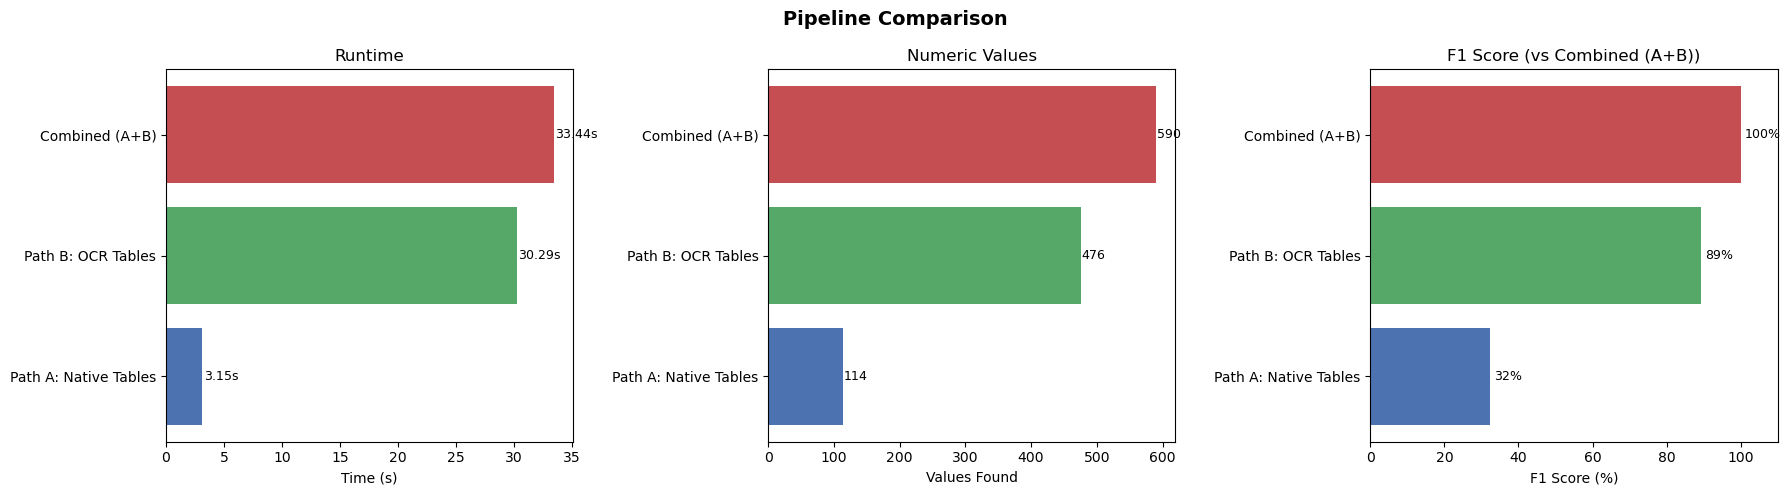

In [78]:
# ── Visualization ──
if len(comparison_rows) >= 2:
    names = [r["pipeline"] for r in comparison_rows]
    vals_count = [r["values"] for r in comparison_rows]
    f1s = [r["f1"] * 100 for r in comparison_rows]
    times = [r["time_s"] for r in comparison_rows]

    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"][:len(names)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Pipeline Comparison", fontsize=14, fontweight="bold")

    # Time
    ax = axes[0]
    bars = ax.barh(names, times, color=colors)
    ax.set_xlabel("Time (s)")
    ax.set_title("Runtime")
    for bar, t in zip(bars, times):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{t:.2f}s", va="center", fontsize=9)

    # Values
    ax = axes[1]
    bars = ax.barh(names, vals_count, color=colors)
    ax.set_xlabel("Values Found")
    ax.set_title("Numeric Values")
    for bar, v in zip(bars, vals_count):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(v), va="center", fontsize=9)

    # F1
    ax = axes[2]
    bars = ax.barh(names, f1s, color=colors)
    ax.set_xlabel("F1 Score (%)")
    ax.set_title(f"F1 Score (vs {baseline_name})")
    ax.set_xlim(0, 110)
    for bar, f in zip(bars, f1s):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{f:.0f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough pipeline results to visualize.")

---
## Summary & Decision Matrix

| Scenario | Recommended Path | Why |
|----------|-----------------|-----|
| Native PDF with embedded text | **Path A** (pdfplumber native) | Fastest, no OCR overhead, highest precision |
| Scanned PDF with vector table grids | **Path B** (pdfplumber grid + targeted OCR) | OCR only on cropped regions, grid from pdfplumber |
| Scanned PDF, no vector elements | **Path B** with full-page fallback | PyMuPDF `get_drawings()` as grid fallback |
| LLM question-answering over PDF | **pymupdf4llm** or **Marker** markdown | Full document context as markdown |
| Structured field extraction | **Path A/B tables** + LLM | DataFrames as structured input to LLM |
| Chart data extraction | **Path A** (vector) or **LLM vision** | Programmatic first, LLM fallback for raster charts |

### Next Steps
- Tune `config.table_settings` for your specific PDF layouts
- Compare Tesseract vs RapidOCR results in the benchmark cell and pick one
- For chart extraction: if vector extraction doesn't work, crop chart images and send to a vision LLM
- Wire the output (tables + markdown + charts) into your downstream LLM pipeline

In [79]:
# Cleanup: close the pdfplumber PDF
pdf.close()
print("Done. PDF closed.")

Done. PDF closed.
